In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
import os
from email import message_from_string
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [9]:
combined_df_csv = r"D:\Northeastern\Fall2025\DS5500\Spam_Email_Detection\notebooks\df_combined.csv"

In [11]:
df = pd.read_csv(combined_df_csv)

In [13]:
df.shape

(130234, 6)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130234 entries, 0 to 130233
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   sender    129621 non-null  object 
 1   receiver  126210 non-null  object 
 2   subject   128090 non-null  object 
 3   body      130232 non-null  object 
 4   urls      130234 non-null  float64
 5   category  130234 non-null  object 
dtypes: float64(1), object(5)
memory usage: 6.0+ MB


In [17]:
df.isnull()

,sender,receiver,subject,body,urls,category
0,False,True,False,False,False,False
1,False,False,False,False,False,False
2,False,True,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
130229,False,False,False,False,False,False
130230,False,False,False,False,False,False
130231,False,False,False,False,False,False
130232,False,False,False,False,False,False


In [19]:
df = df.dropna(how='any')
df.reset_index(drop=True, inplace=True)

In [21]:
df.shape

(124352, 6)

In [23]:
df.head(3)

,sender,receiver,subject,body,urls,category
0,cPanel <service@cpanel.com>,jose@monkey.org,Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1.0,phishing
1,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0.0,phishing
2,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1.0,phishing


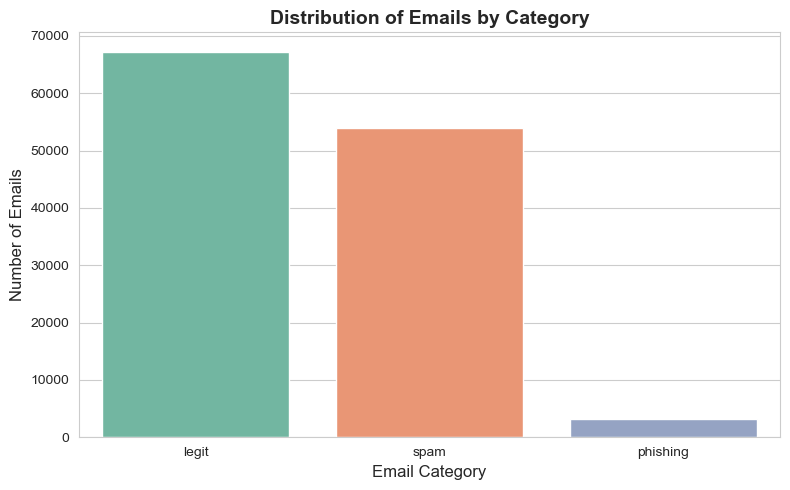

In [25]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.countplot(x='category', data=df, palette='Set2', order=df['category'].value_counts().index)

plt.title("Distribution of Emails by Category", fontsize=14, fontweight='bold')
plt.xlabel("Email Category", fontsize=12)
plt.ylabel("Number of Emails", fontsize=12)

plt.tight_layout()
plt.show()

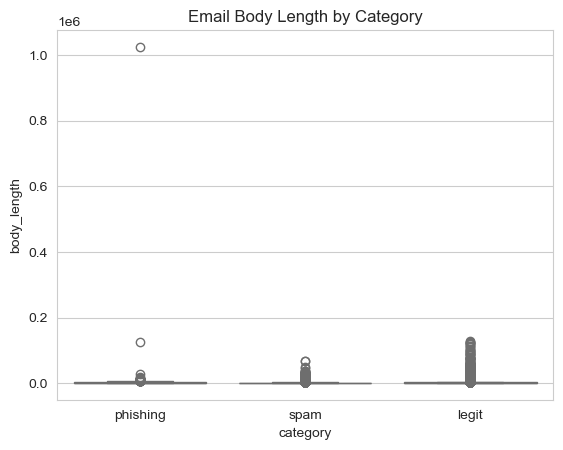

In [27]:
df['body_length'] = df['body'].apply(len)

sns.boxplot(x='category', y='body_length', data=df, palette='coolwarm')
plt.title("Email Body Length by Category")
plt.show()

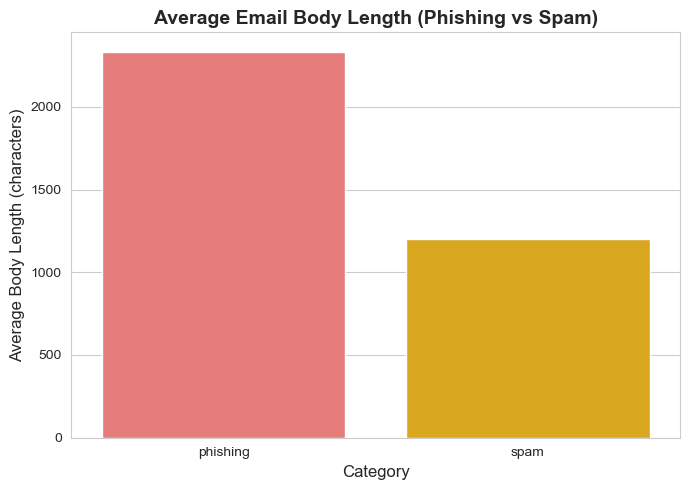

In [29]:
malicious_df = df[df['category'].isin(['phishing', 'spam'])].copy()
malicious_df['body_length'] = malicious_df['body'].apply(lambda x: len(str(x)))
avg_length = malicious_df.groupby('category')['body_length'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x='category', y='body_length', data=avg_length, palette=['#f76c6c', '#f8b400'])
plt.title("Average Email Body Length (Phishing vs Spam)", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Average Body Length (characters)", fontsize=12)

plt.tight_layout()
plt.show()

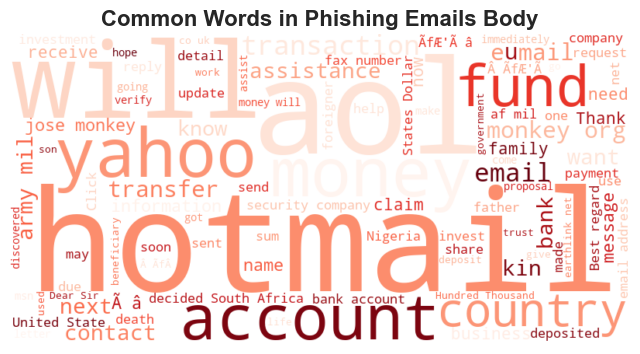

In [31]:
phishing_text = " ".join(df[df['category'] == 'phishing']['body'].astype(str).tolist())

plt.figure(figsize=(8,6))
wc_phishing = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Reds', max_words=100).generate(phishing_text)
plt.imshow(wc_phishing, interpolation='bilinear')
plt.axis('off')
plt.title("Common Words in Phishing Emails Body", fontsize=16, fontweight='bold')
plt.show()

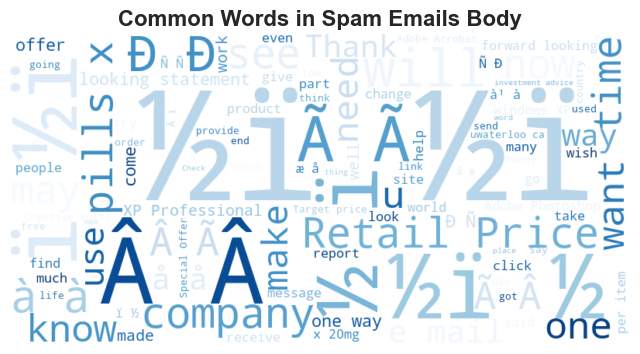

In [32]:
spam_text = " ".join(df[df['category'] == 'spam']['body'].astype(str).tolist())

plt.figure(figsize=(8,6))
wc_spam = WordCloud(width=800, height=400, background_color='white', 
                    colormap='Blues', max_words=100).generate(spam_text)
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Common Words in Spam Emails Body", fontsize=16, fontweight='bold')
plt.show()